**Programming Assignment 2**

**Name:** KHAN, Zeeshan Alam

**Group No:** 65

**What are we doing:** We are building a machine learning model that can predict whether a person earns more or less than $50,000/year, based on information like their age, education, job type, marital status, etc.

## **Task 1 Step 1**

First we have connected our Colab file to our Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Next, we have read and loaded both the train and test file.

In [19]:
import pandas as pd

# Load adult_train.csv
train = pd.read_csv('/content/drive/MyDrive/adult_train.csv')

# Load adult_test.csv
test = pd.read_csv('/content/drive/MyDrive/adult_test.csv')

Now, we display to see if we have loaded the train and test files correctly.

In [20]:
# Display to see the adult_train.csv file
train.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,27,Private,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Female,0,0,44,United-States,<=50K
1,27,Private,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,<=50K
2,25,Private,Assoc-acdm,12,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,<=50K
3,46,Private,5th-6th,3,Married-civ-spouse,Transport-moving,Husband,Amer-Indian-Eskimo,Male,0,1902,40,United-States,<=50K
4,45,Private,11th,7,Divorced,Transport-moving,Not-in-family,White,Male,0,2824,76,United-States,>50K


In [21]:
# Display to see the adult_test.csv file
test.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


Next, we need to split the data into the input part 'X' which is all columns except the target column, and the output part 'Y' which is the target column.

In [5]:
# Split the training data into input (X_train) and output (Y_train)
X_train = train.drop('target', axis=1)
Y_train = train['target']

# Split the test data into input (X_test) and output (Y_test)
X_test = test.drop('target', axis=1)
Y_test = test['target']

Now, we display to see if we have divided the data into X and Y correctly.

In [22]:
X_train.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,27,Private,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Female,0,0,44,United-States
1,27,Private,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States
2,25,Private,Assoc-acdm,12,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States
3,46,Private,5th-6th,3,Married-civ-spouse,Transport-moving,Husband,Amer-Indian-Eskimo,Male,0,1902,40,United-States
4,45,Private,11th,7,Divorced,Transport-moving,Not-in-family,White,Male,0,2824,76,United-States


In [23]:
Y_train.head()

,target
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,>50K


## **Task 1 Step 2:**

The core problem is that scikit-learn only understands numbers, but your dataset has text columns like workclass = "Private" or education = "Bachelors". We use One-Hot encoding to convert these categorical features into numbers.

In [8]:
from sklearn.feature_extraction import DictVectorizer

dicts_for_my_training_data_X = X_train.to_dict('records')
dicts_for_my_test_data_X = X_test.to_dict('records')

dv = DictVectorizer()

X_train_encoded = dv.fit_transform(dicts_for_my_training_data_X)

# Provided on Canvas: To handle the test data, you just call transform, because this time the vectorizer does not need to be "trained." We use this to compute the accuracy on the test set.

X_test_encoded = dv.transform(dicts_for_my_test_data_X)


Now we compute a cross-validation accuracy for the training set using one of the classifiers you explored in Programming Assignment 1. The classifier we are using here is Decision Tree Classifier.

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score


best_max_depth_value = - 1
max_accuracy = - 1


for count in range(1, 16):

  # Initialize a Logistic Regression classifier
  classifier = DecisionTreeClassifier(max_depth = count)

  # Compute cross-validation accuracy on the training set
  cv_scores = cross_val_score(classifier, X_train_encoded, Y_train)

  if cv_scores.mean() > max_accuracy:
    max_accuracy = cv_scores.mean()
    best_max_depth_value = count

  print("max_depth value: ", count)
  print("Average cross-validation accuracy: ", cv_scores.mean())
  print()


print("The best max_depth value is: ", best_max_depth_value)
print("The best average cross-validation accuracy is: ", max_accuracy)

max_depth value:  1
Average cross-validation accuracy:  0.7591904454179904

max_depth value:  2
Average cross-validation accuracy:  0.8282301726164002

max_depth value:  3
Average cross-validation accuracy:  0.8437702604618773

max_depth value:  4
Average cross-validation accuracy:  0.8443845110761279

max_depth value:  5
Average cross-validation accuracy:  0.8489913152338302

max_depth value:  6
Average cross-validation accuracy:  0.8545499767805158

max_depth value:  7
Average cross-validation accuracy:  0.8554098852003044

max_depth value:  8
Average cross-validation accuracy:  0.8551948833385958

max_depth value:  9
Average cross-validation accuracy:  0.8551335054329066

max_depth value:  10
Average cross-validation accuracy:  0.857836099677417

max_depth value:  11
Average cross-validation accuracy:  0.8572832929868859

max_depth value:  12
Average cross-validation accuracy:  0.8551028117644884

max_depth value:  13
Average cross-validation accuracy:  0.8526766397275379

max_depth

Now we are going to calculate the accuracy of the Decision Tree Classifier on the test set.

In [10]:
from sklearn.metrics import accuracy_score

print("max_depth we are using in Task 1 Step 2: ", best_max_depth_value)

# Initialize the classifier with the best depth found during cross-validation
best_classifier = DecisionTreeClassifier(max_depth=best_max_depth_value)

best_classifier.fit(X_train_encoded, Y_train)

Y_test_pred_dt = best_classifier.predict(X_test_encoded)

accuracy_score(Y_test, Y_test_pred_dt)

print(f"Best Decision Tree (max_depth={best_max_depth_value}) accuracy on the test set: {accuracy_score(Y_test, Y_test_pred_dt)}")

max_depth we are using in Task 1 Step 2:  10
Best Decision Tree (max_depth=10) accuracy on the test set: 0.8606965174129353


## **Task 1 Step 3:**

In this step, we build a pipeline that includes the classifier that we selected previously (Decision Tree Classifier), and make sure that it works.

In [11]:
from sklearn.pipeline import make_pipeline

print("max_depth we are using in Task 1 Step 3: ", best_max_depth_value)

# Build the pipeline with DictVectorizer and DecisionTreeClassifier. This is provided on canvas
pipeline = make_pipeline(
    DictVectorizer(),
    DecisionTreeClassifier(max_depth=best_max_depth_value)
)

# Fit the pipeline to the training data
pipeline.fit(X_train.to_dict('records'), Y_train)

# Make predictions on the test data
Y_guess = pipeline.predict(X_test.to_dict('records'))

# Calculate the accuracy of the pipeline's predictions
accuracy = accuracy_score(Y_test, Y_guess)

print(f"Pipeline accuracy on the test set: ", accuracy)

max_depth we are using in Task 1 Step 3:  10
Pipeline accuracy on the test set:  0.8613107302991216


## **Task 2: Decision trees and random forests**

**Task 2 Part 1:** Investigate underfitting and overfitting for DecisionTreeClassifier as a function of max_depth. The evaluation metric that we use for this classification is accuracy.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Lists to store accuracy scores
train_accuracies_dt = []
test_accuracies_dt = []


for depth in range(1, 13):

    dt_classifier = DecisionTreeClassifier(max_depth=depth)

    dt_classifier.fit(X_train_encoded, Y_train)

    # Calculate training accuracy

    y_train_pred = dt_classifier.predict(X_train_encoded)

    train_acc = accuracy_score(Y_train, y_train_pred)

    train_accuracies_dt.append(train_acc)

    # Calculate test accuracy

    y_test_pred = dt_classifier.predict(X_test_encoded)

    test_acc = accuracy_score(Y_test, y_test_pred)

    test_accuracies_dt.append(test_acc)

    print(f"Max Depth: ", depth, "| Training Accuracy: ", train_acc, "| Test Accuracy: ", test_acc)

Max Depth:  1 | Training Accuracy:  0.7591904425539756 | Test Accuracy:  0.7637737239727289
Max Depth:  2 | Training Accuracy:  0.8282300912134148 | Test Accuracy:  0.8306615072784227
Max Depth:  3 | Training Accuracy:  0.8438930008292128 | Test Accuracy:  0.8447884036607088
Max Depth:  4 | Training Accuracy:  0.8438930008292128 | Test Accuracy:  0.8447884036607088
Max Depth:  5 | Training Accuracy:  0.8519701483369675 | Test Accuracy:  0.8522818008721823
Max Depth:  6 | Training Accuracy:  0.8570989834464543 | Test Accuracy:  0.8575026104047663
Max Depth:  7 | Training Accuracy:  0.8583888701206965 | Test Accuracy:  0.8568883975185799
Max Depth:  8 | Training Accuracy:  0.8605386812444336 | Test Accuracy:  0.856704133652724
Max Depth:  9 | Training Accuracy:  0.8639476674549308 | Test Accuracy:  0.8588538787543762
Max Depth:  10 | Training Accuracy:  0.8693836184392372 | Test Accuracy:  0.8610036238560285
Max Depth:  11 | Training Accuracy:  0.873775375449157 | Test Accuracy:  0.85983

Now, let's visualize the training and test accuracies for the Decision Tree Classifier across different `max_depth` values. This plot will clearly show the underfitting and overfitting behavior.

Plotting DecisionTreeClassifier experiment results:


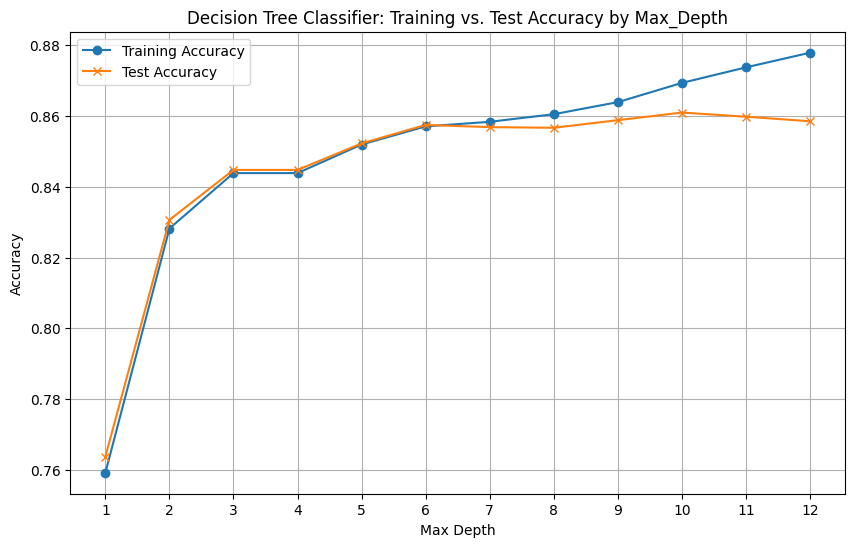

In [13]:
print("Plotting DecisionTreeClassifier experiment results:")
plt.figure(figsize=(10, 6))
plt.plot(range(1,13), train_accuracies_dt, label='Training Accuracy', marker='o')
plt.plot(range(1,13), test_accuracies_dt, label='Test Accuracy', marker='x')
plt.title('Decision Tree Classifier: Training vs. Test Accuracy by Max_Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(range(1,13))
plt.grid(True)
plt.legend()
plt.show()

**Task 2 Part 2:** Underfitting and Overfitting in Random Forest Classifiers

Now, we'll replace the DecisionTreeClassifier with a RandomForestClassifier and investigate how the number of trees n_estimators affects the underfitting/overfitting curve, while still varying max_depth.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import time

n_estimators_range = [1, 10, 50, 100, 150, 200, 250, 300]
max_depth_range = range(1, 13)

# Dictionary to store accuracies and training times
rf_train_accuracies = {}
rf_test_accuracies = {}
rf_training_times = {}

print("Investigating RandomForestClassifier performance and training time:")

for n_estimators_val in n_estimators_range:
    print(f"\n--- Testing with n_estimators = {n_estimators_val} ---")
    current_train_accs = []
    current_test_accs = []

    start_time = time.time()

    for depth in max_depth_range:
        # n_jobs=-1 uses all available processors for faster computation
        rf_classifier = RandomForestClassifier(n_estimators=n_estimators_val, max_depth=depth, random_state=42, n_jobs=-1)

        # Train the classifier
        rf_classifier.fit(X_train_encoded, Y_train)

        # Calculate training accuracy
        y_train_pred_rf = rf_classifier.predict(X_train_encoded)
        train_acc_rf = accuracy_score(Y_train, y_train_pred_rf)
        current_train_accs.append(train_acc_rf)

        # Calculate test accuracy
        y_test_pred_rf = rf_classifier.predict(X_test_encoded)
        test_acc_rf = accuracy_score(Y_test, y_test_pred_rf)
        current_test_accs.append(test_acc_rf)

        print(f"  Depth: {depth} | Train Acc: {train_acc_rf} | Test Acc: {test_acc_rf}")

    end_time = time.time()
    elapsed_time = end_time - start_time
    rf_training_times[n_estimators_val] = elapsed_time

    rf_train_accuracies[n_estimators_val] = current_train_accs
    rf_test_accuracies[n_estimators_val] = current_test_accs

    print(f"Total training time for n_estimators={n_estimators_val}: {elapsed_time:.2f} seconds")

Investigating RandomForestClassifier performance and training time:

--- Testing with n_estimators = 1 ---
  Depth: 1 | Train Acc: 0.8026166272534627 | Test Acc: 0.8049259873472145
  Depth: 2 | Train Acc: 0.8026166272534627 | Test Acc: 0.8049259873472145
  Depth: 3 | Train Acc: 0.8026166272534627 | Test Acc: 0.8049259873472145
  Depth: 4 | Train Acc: 0.8190473265563097 | Test Acc: 0.8193599901725939
  Depth: 5 | Train Acc: 0.8190166149688277 | Test Acc: 0.8192371475953566
  Depth: 6 | Train Acc: 0.82171923466724 | Test Acc: 0.8221239481604324
  Depth: 7 | Train Acc: 0.8299499401124044 | Test Acc: 0.8296173453719059
  Depth: 8 | Train Acc: 0.8319154817112496 | Test Acc: 0.8306615072784227
  Depth: 9 | Train Acc: 0.83600012284635 | Test Acc: 0.8339168355752103
  Depth: 10 | Train Acc: 0.8471177175148183 | Test Acc: 0.8466310423192679
  Depth: 11 | Train Acc: 0.8516937440496299 | Test Acc: 0.8440513481972852
  Depth: 12 | Train Acc: 0.8263566843770155 | Test Acc: 0.8176401940912721
Total 

Now, let's visualize the training and test accuracies for the Random Forest Classifier across different max_depth values for each n_estimators.


Plotting RandomForestClassifier experiment results:


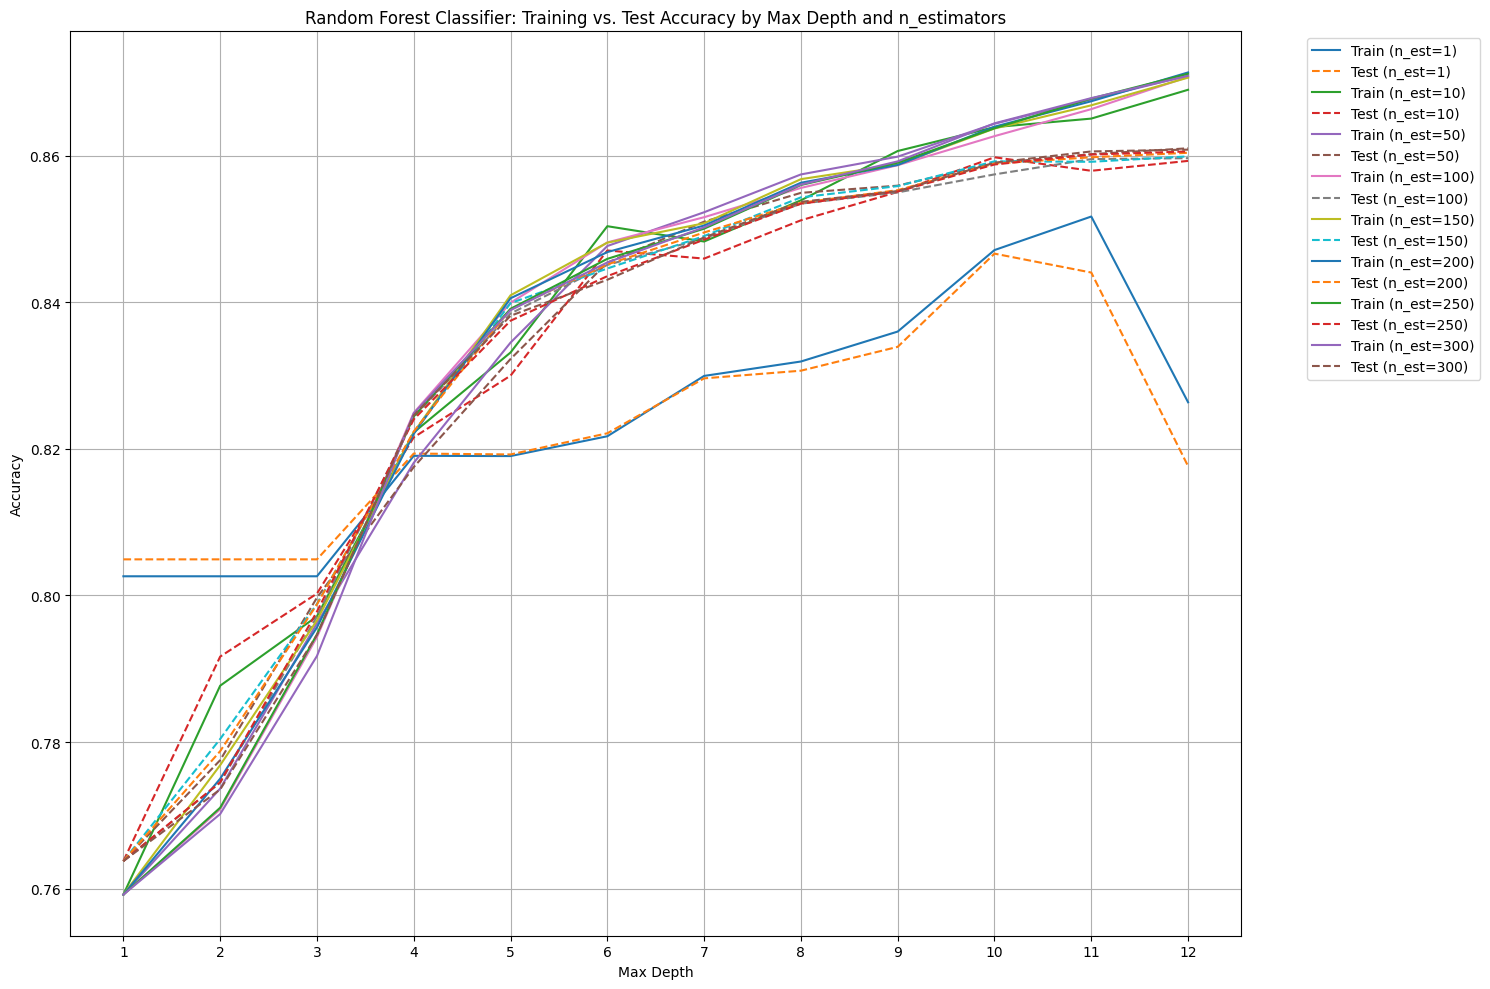

In [15]:
print("\nPlotting RandomForestClassifier experiment results:")

plt.figure(figsize=(15, 10))

for n_estimators_val in n_estimators_range:
    plt.plot(max_depth_range, rf_train_accuracies[n_estimators_val], label=f'Train (n_est={n_estimators_val})', linestyle='-')
    plt.plot(max_depth_range, rf_test_accuracies[n_estimators_val], label=f'Test (n_est={n_estimators_val})', linestyle='--')

plt.title('Random Forest Classifier: Training vs. Test Accuracy by Max Depth and n_estimators')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(list(max_depth_range))
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Question 1:** What's the difference between the curve for a decision tree and for a random forest with an ensemble size of 1, and why do we see this difference?

1) The random forest with an ensemble size of 1  has lower accuracy than the decision tree across almost all depths. The reason is, that at every split, the random forest tree only gets to consider a random subset of features rather than all of them, meaning it is often forced into a suboptimal split early on, which compounds as the tree grows deeper. The decision tree on the other hand always searches every feature and picks the absolute best split available, which is why its accuracy climbs faster and higher.

2) The random forest train and test lines stay very close together throughout because the forced randomness prevents it from memorizing the training data, so there's very little overfitting. The decision tree meanwhile shows a growing gap between train and test as depth increases, which is a sign of increased overfitting.


Plotting comparison of Decision Tree and Random Forest (n_estimators=1):


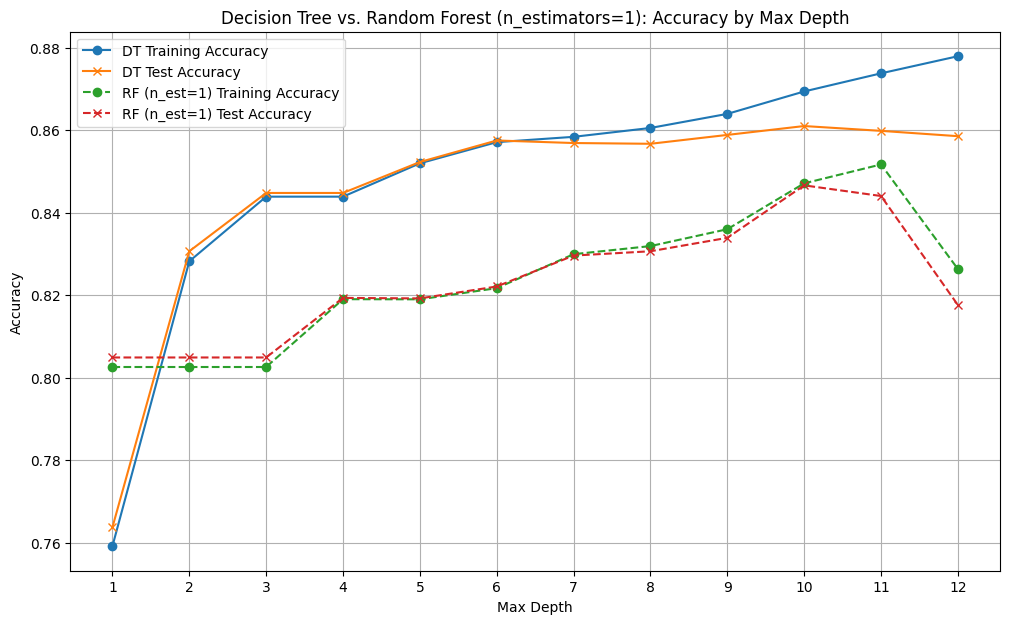

In [16]:
import matplotlib.pyplot as plt

print("Plotting comparison of Decision Tree and Random Forest (n_estimators=1):")
plt.figure(figsize=(12, 7))

# Plot for Decision Tree
plt.plot(range(1, 13), train_accuracies_dt, label='DT Training Accuracy', marker='o', linestyle='-')
plt.plot(range(1, 13), test_accuracies_dt, label='DT Test Accuracy', marker='x', linestyle='-')

# Plot for Random Forest with n_estimators=1
# Note: rf_train_accuracies[1] and rf_test_accuracies[1] are available from previous execution
plt.plot(range(1, 13), rf_train_accuracies[1], label='RF (n_est=1) Training Accuracy', marker='o', linestyle='--')
plt.plot(range(1, 13), rf_test_accuracies[1], label='RF (n_est=1) Test Accuracy', marker='x', linestyle='--')

plt.title('Decision Tree vs. Random Forest (n_estimators=1): Accuracy by Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.xticks(range(1, 13))
plt.grid(True)
plt.legend()
plt.show()

**Question 2:** What happens with the curve for random forests as the ensemble size grows?

1) With n_estimators=1, the curves are unstable because a single random tree is highly sensitive to which features happened to get sampled. As n_estimators increase, individual randomness gets averaged out and the curves become as smooth as the Decision Tree curve.

2) The overall accuracy increases, which is seen by the fact that the entire curve shifts upward as more trees are added. This happens because averaging many trees reduces the chance that a wrong prediction by one poorly-sampled tree brings the overall accuracy down.

3) The train/test accuracy gap stays small even as ensemble size grows. With the Decision Tree Classifier, this gap widens with depth, and that widening gap is overfitting. Random forest avoids this because averaging many randomized trees cancels out the memorization effect, keeping train and test accuracy close together even at large depths.


**Question 3:** What happens with the best observed test set accuracy as the ensemble size grows?


n_estimators: 1
Best Observed Test Accuracy: 0.8466

n_estimators: 10
Best Observed Test Accuracy: 0.8598

n_estimators: 50
Best Observed Test Accuracy: 0.8610

n_estimators: 100
Best Observed Test Accuracy: 0.8597

n_estimators: 150
Best Observed Test Accuracy: 0.8599

n_estimators: 200
Best Observed Test Accuracy: 0.8604

n_estimators: 250
Best Observed Test Accuracy: 0.8606

n_estimators: 300
Best Observed Test Accuracy: 0.8608

The jump from 1 to 10 trees is huge. From 10 to 50 the gain is much smaller, and beyond 100 we are getting a negligible amount of improvement. This is a well-known property of random forests where we hit a point of diminishing returns where adding more trees costs computation but buys us almost nothing in accuracy.


**Question 4:** What happens with the training time as the ensemble size grows?

Training time scales roughly linearly with n_estimators because each tree is built independently from scratch. Going from 10 to 100 trees means roughly 10x longer training.

Training Time Summary:
n_estimators: 1 | Time: 1.23 seconds
n_estimators: 10 | Time: 3.90 seconds
n_estimators: 50 | Time: 11.79 seconds
n_estimators: 100 | Time: 21.86 seconds
n_estimators: 150 | Time: 31.46 seconds
n_estimators: 200 | Time: 41.31 seconds
n_estimators: 250 | Time: 50.91 seconds
n_estimators: 300 | Time: 60.75 seconds


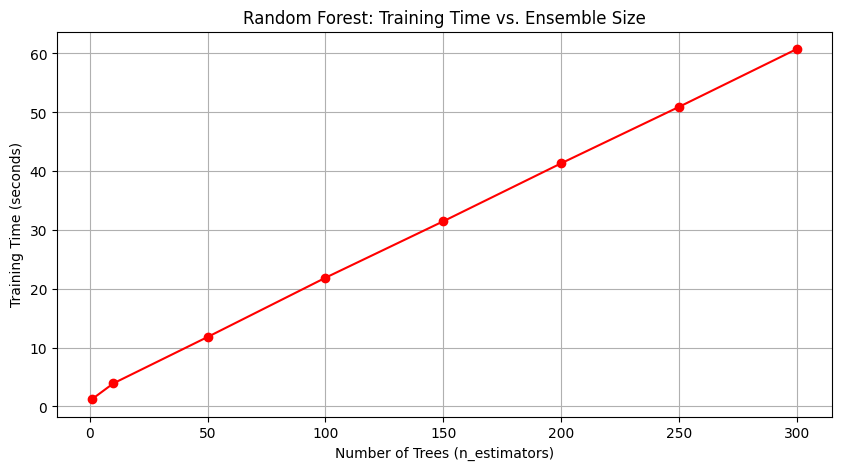

In [17]:
import matplotlib.pyplot as plt

# Display the recorded times
print("Training Time Summary:")
for n_est, t in rf_training_times.items():
    print(f"n_estimators: {n_est} | Time: {t:.2f} seconds")

# Plotting the timing results for Question 4
plt.figure(figsize=(10, 5))
plt.plot(list(rf_training_times.keys()), list(rf_training_times.values()), marker='o', color='red')
plt.title('Random Forest: Training Time vs. Ensemble Size')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Training Time (seconds)')
plt.grid(True)
plt.show()

## **Task 3**

**Task at hand**: Sort the features by importance scores in reverse order (so that the most important feature comes first), inspect the first few of these features, and try to reason about why you got this result.

In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

# Re-building the pipeline with a Random Forest for Task 3 analysis
rf_pipeline = make_pipeline(
    DictVectorizer(),
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
)

rf_pipeline.fit(X_train.to_dict('records'), Y_train)

# Get feature names and importance scores
feature_names = rf_pipeline.steps[0][1].get_feature_names_out()
importances = rf_pipeline.steps[1][1].feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort by importance in reverse order
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Top 15 Most Important Features:")
display(feature_importance_df.head(15))

Top 15 Most Important Features:


,feature,importance
1,capital-gain,0.165314
23,marital-status=Married-civ-spouse,0.132880
90,relationship=Husband,0.107859
3,education-num,0.097990
25,marital-status=Never-married,0.060007
0,age,0.054412
20,hours-per-week,0.044961
2,capital-loss,0.031833
80,occupation=Prof-specialty,0.028551
74,occupation=Exec-managerial,0.027845


### **Task 3 Analysis**

The most important features identified by the Random Forest model include capital-gain, marital-status (Married-civ-spouse), relationship (Husband), education-num, and age. These features appear at the top because they are highly effective at splitting the data into groups that distinguish between high-income and low-income individuals. For example, capital gain is a strong indicator of financial status, while education level and age are commonly associated with earning potential.

However, it is important to note that feature importance scores in Random Forests only measure how useful a feature is for discriminating between classes. They do not indicate the direction of the relationship between a feature and the target variable. In other words, even though a feature like capital-gain is highly important, this does not necessarily mean that increasing its value always increases the likelihood of being a high earner. The model may simply be using it to make effective splits in the data.

An alternative way to measure feature importance is permutation feature importance. This method works by randomly shuffling the values of one feature and then checking how much the model’s performance worsens. If the performance drops significantly, it means the model was relying on that feature, so it is considered important. If there is little or no change, the feature is likely not very important. Unlike the default feature importance used in Random Forests, this method directly measures how much each feature affects the model’s predictions, and it can be applied to any type of model, making it more reliable.